Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

Loading Data

In [2]:
src = "participant_input.csv"
df = pd.read_csv(src)
df = df[~df['name'].isin(['Briant', 'B'])]

In [3]:
ground_truth = np.array([0, 1, 1, 1, 1, 1, 0, 0, 0, 0], dtype=bool)
actual_phishing_count = ground_truth.sum()
phishing_cols = [f'is_phishing_email_{i}' for i in range(1, 11)]
rt_cols       = [f'response_time_email_{i}' for i in range(1, 11)]
conf_cols     = [f'confidence_level_email_{i}' for i in range(1, 11)]

group_map = {
    'control':  'Scenario 1: Control',
    'lime':     'Scenario 2: LIME Assisted',
    'word2vec': 'Scenario 3: IG Assisted',
}

n_phish = ground_truth.sum()     
n_legit = (~ground_truth).sum()  


Exploratory Data Analysis

In [4]:
df_eda = df.copy()

In [5]:
# Feature Engineering
phishing_cols = [c for c in df.columns if c.startswith("is_phishing_email_")]
rt_cols = [c for c in df.columns if c.startswith("response_time_email_")]
conf_cols = [c for c in df.columns if c.startswith("confidence_level_email_")]

df["phishing_flag_rate"] = df[phishing_cols].mean(axis=1) # % of emails flagged as phishing
df["avg_response_time_sec"] = df[rt_cols].mean(axis=1) / 1000
df["avg_confidence"] = df[conf_cols].mean(axis=1)
df["phishing_flag_count"] = df[phishing_cols].sum(axis=1)

In [6]:
# Summary
print("=" * 60)
print(f"Total participants: {len(df)}")
print("\nParticipants per group:")
print(df["group_type"].value_counts())
 
print("\nOverall descriptive stats (participant-level aggregates):")
print(df[["phishing_flag_rate", "avg_response_time_sec", "avg_confidence", "helpfulness"]].describe().round(2))
 
print("\nSame stats broken down by group:")
print(df.groupby("group_type")[["phishing_flag_rate", "avg_response_time_sec", "avg_confidence", "helpfulness"]].describe().round(2))
 
print(f"\n'helpfulness' missing: {df['helpfulness'].isna().sum()} "
      f"(expected for 'control' group, which had no explanation tool to rate)")


Total participants: 156

Participants per group:
group_type
word2vec    54
control     52
lime        50
Name: count, dtype: int64

Overall descriptive stats (participant-level aggregates):
       phishing_flag_rate  avg_response_time_sec  avg_confidence  helpfulness
count              156.00                 156.00          156.00       104.00
mean                 0.50                  12.66            4.04         3.93
std                  0.18                   9.19            0.54         1.06
min                  0.00                   0.87            2.40         1.00
25%                  0.40                   5.65            3.70         3.00
50%                  0.50                   9.97            4.00         4.00
75%                  0.60                  17.64            4.40         5.00
max                  1.00                  44.13            5.00         5.00

Same stats broken down by group:
           phishing_flag_rate                                       \
    


Dashboard saved to distribution_dashboard.png


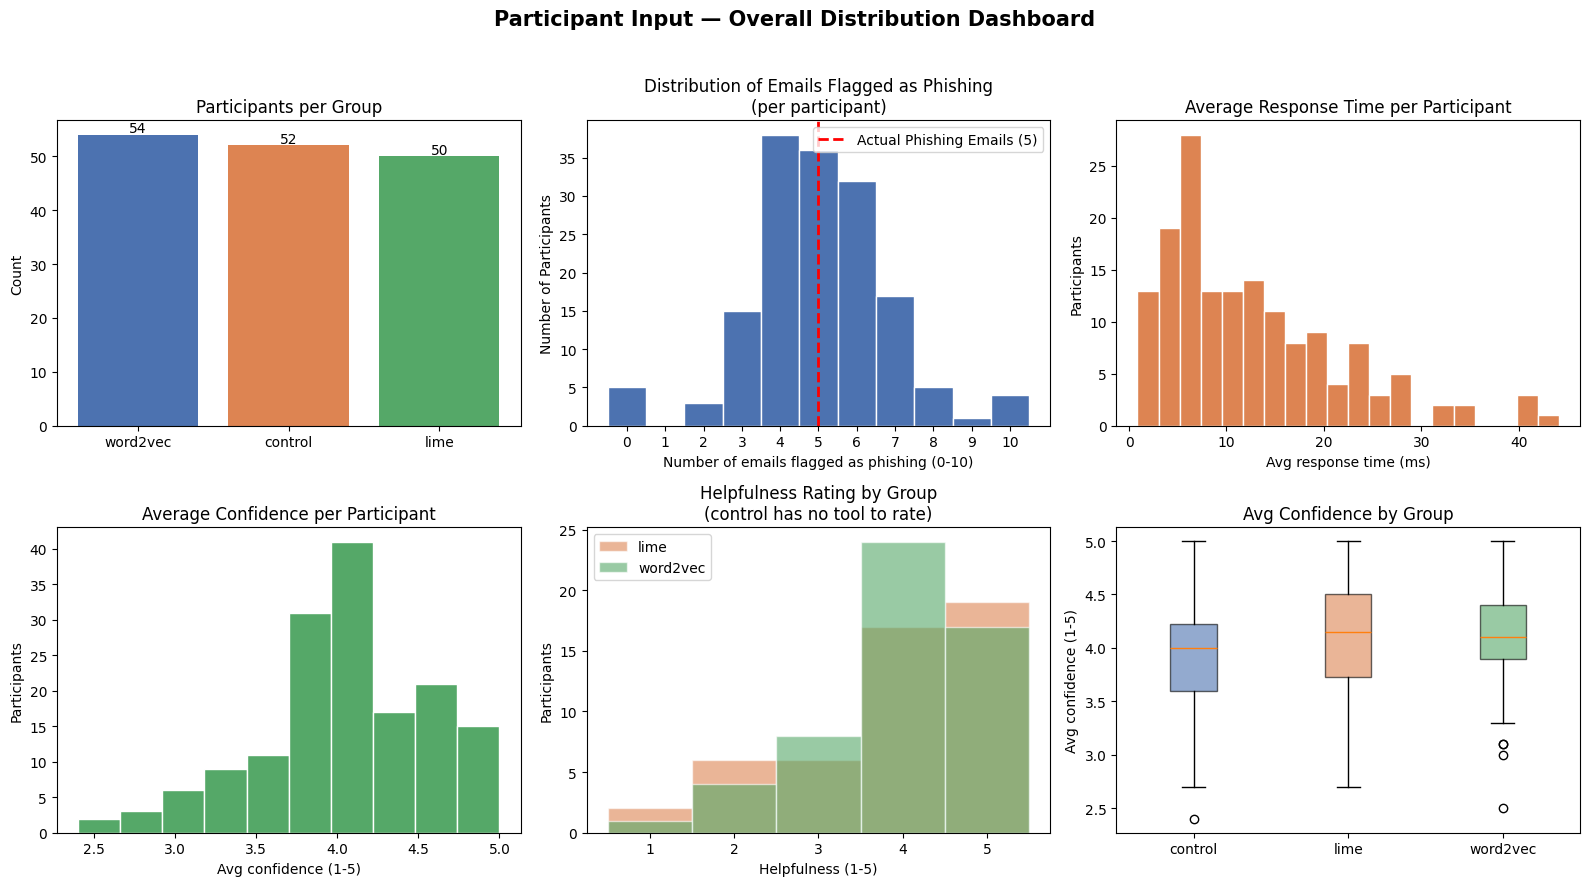

In [7]:
# Dashboard
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Participant Input — Overall Distribution Dashboard", fontsize=15, fontweight="bold")
 
# 1. Group sizes
ax = axes[0, 0]
counts = df["group_type"].value_counts()
ax.bar(counts.index, counts.values, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_title("Participants per Group")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, str(v), ha="center")
 
# 2. Phishing flag rate distribution
ax = axes[0, 1]
ax.hist(df["phishing_flag_count"], bins=np.arange(-0.5, 11.5, 1), color="#4C72B0", edgecolor="white")

# 3. Add a vertical line for the ground truth comparison
ax.axvline(actual_phishing_count, color='red', linestyle='dashed', linewidth=2, 
           label=f'Actual Phishing Emails ({actual_phishing_count})')

# 4. Format labels, ticks, and add a legend
ax.set_title("Distribution of Emails Flagged as Phishing\n(per participant)")
ax.set_xlabel("Number of emails flagged as phishing (0-10)")
ax.set_ylabel("Number of Participants")
ax.set_xticks(range(11))
ax.legend() # Displays the label we set in axvline

# 3. Average response time distribution (log scale due to long tail)
ax = axes[0, 2]
ax.hist(df["avg_response_time_sec"], bins=20, color="#DD8452", edgecolor="white")
ax.set_title("Average Response Time per Participant")
ax.set_xlabel("Avg response time (ms)")
ax.set_ylabel("Participants")
 
# 4. Average confidence distribution
ax = axes[1, 0]
ax.hist(df["avg_confidence"], bins=10, color="#55A868", edgecolor="white")
ax.set_title("Average Confidence per Participant")
ax.set_xlabel("Avg confidence (1-5)")
ax.set_ylabel("Participants")
 
# 5. Helpfulness distribution by group (only lime/word2vec have data)
ax = axes[1, 1]
for grp, color in zip(["lime", "word2vec"], ["#DD8452", "#55A868"]):
    vals = df.loc[df["group_type"] == grp, "helpfulness"].dropna()
    ax.hist(vals, bins=np.arange(0.5, 6.5, 1), alpha=0.6, label=grp, color=color, edgecolor="white")
ax.set_title("Helpfulness Rating by Group\n(control has no tool to rate)")
ax.set_xlabel("Helpfulness (1-5)")
ax.set_ylabel("Participants")
ax.set_xticks(range(1, 6))
ax.legend()
 
# 6. Avg confidence by group (boxplot)
ax = axes[1, 2]
groups = ["control", "lime", "word2vec"]
data = [df.loc[df["group_type"] == g, "avg_confidence"].dropna() for g in groups]
bp = ax.boxplot(data, tick_labels=groups, patch_artist=True)
for patch, color in zip(bp["boxes"], ["#4C72B0", "#DD8452", "#55A868"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_title("Avg Confidence by Group")
ax.set_ylabel("Avg confidence (1-5)")
 
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("distribution_dashboard.png", dpi=150)
print(f"\nDashboard saved to distribution_dashboard.png")

Computing per-participant metrics

In [8]:
group_metrics = {}
for group in ['control', 'lime', 'word2vec']:
    g = df[df['group_type'] == group].dropna(subset=rt_cols + conf_cols)
    responses = g[phishing_cols].values.astype(bool)

    tp = np.sum((responses == True)  & (ground_truth == True),  axis=1)
    fp = np.sum((responses == True)  & (ground_truth == False), axis=1)
    tn = np.sum((responses == False) & (ground_truth == False), axis=1)

    hit_rate = (tp + 0.5) / (n_phish + 1)
    fa_rate  = (fp + 0.5) / (n_legit + 1)

    d_prime   = stats.norm.ppf(hit_rate) - stats.norm.ppf(fa_rate)
    c         = -0.5 * (stats.norm.ppf(hit_rate) + stats.norm.ppf(fa_rate))
    accuracy  = (tp + tn) / 10.0
    conf      = g[conf_cols].values / 5.0
    probs     = np.where(responses == True, conf, 1 - conf)
    brier     = np.mean((probs - ground_truth.astype(float)) ** 2, axis=1)
    latency_s = np.mean(g[rt_cols].values, axis=1) / 1000.0

    group_metrics[group] = {
        'accuracy': accuracy,
        'd_prime':  d_prime,
        'c':        c,
        'brier':    brier,
        'latency':  latency_s,
    }

Descriptive Statistics

In [9]:
metric_labels = {
    'accuracy': 'Accuracy',
    'd_prime':  "Sensitivity (d')",
    'c':        'Bias (c)',
    'brier':    'Brier Score',
    'latency':  'Latency (s)',
}

# Updated to match the row names in the provided table image
group_labels = {
    'control':  'Scenario 1: Control',
    'lime':     'Scenario 2: LIME Assisted',
    'word2vec': 'Scenario 3: IG Assisted',
}

print("=" * 125)
print(f"{'SECTION 2: DESCRIPTIVE STATISTICS (mean ± sd)':^125}")
print("=" * 125)

# 1. Print the header row
header_row = f"{'Scenario':<26}"
for mlabel in metric_labels.values():
    header_row += f" | {mlabel:<16}"
print(header_row)
print("-" * 125)

# 2. Iterate through groups (rows) first, then metrics (columns)
for g, glabel in group_labels.items():
    row_str = f"{glabel:<26}"
    for m in metric_labels.keys():
        vals = group_metrics[g][m]
        # Format the cell as 'mean ± sd'
        cell_val = f"{vals.mean():.4f} ± {vals.std():.4f}"
        row_str += f" | {cell_val:<16}"
    print(row_str)
    
print("-" * 125)

                                        SECTION 2: DESCRIPTIVE STATISTICS (mean ± sd)                                        
Scenario                   | Accuracy         | Sensitivity (d') | Bias (c)         | Brier Score      | Latency (s)     
-----------------------------------------------------------------------------------------------------------------------------
Scenario 1: Control        | 0.6327 ± 0.1718  | 0.6428 ± 0.8690  | 0.0700 ± 0.6454  | 0.2692 ± 0.1095  | 14.1038 ± 9.4193
Scenario 2: LIME Assisted  | 0.7880 ± 0.1194  | 1.4500 ± 0.6752  | -0.0498 ± 0.3816 | 0.1810 ± 0.1018  | 14.4095 ± 10.3079
Scenario 3: IG Assisted    | 0.7926 ± 0.1331  | 1.4741 ± 0.7257  | -0.0730 ± 0.4069 | 0.1645 ± 0.0812  | 9.6591 ± 6.6732 
-----------------------------------------------------------------------------------------------------------------------------


**Key Takeaways**
1. **Better Accuracy & Detection**: LIME and IG assistance both boosted accuracy from 63% in the control group to roughly 79% in the assisted scenarios. XAI assistance also more than doubled the sensitivity (d') score (0.64 → ~1.45–1.47), meaning users were substantially better at distinguishing "signal" from "noise" when assisted.

2. **Fasted Decisions Overall**  Latency tells a more nuanced story than a simple downward trend. Control group latency was 14.10s, and LIME assistance did not speed things up — it was essentially flat, even ticking up slightly to 14.41s. IG assistance, however, cut latency substantially to 9.66s, making it the only condition that meaningfully improved decision speed, roughly 4.4s faster than control and 4.7s faster than LIME.

3. **Higher Quality Predictions**: Using the Brier Score (lower is better), assisted scenarios lowered the score from 0.27 in control to about 0.16–0.18, indicating that users' confidence and accuracy were better calibrated when they had help (LIME: 0.18, IG: 0.16).

4. **Slight Shift in Bias**
    * **Control Group** (Bias = +0.07) without assistance, users were conservative — they needed stronger, more obvious evidence before making a positive identification.
    * **Assisted Groups** (Bias = -0.05 to -0.07): with LIME or IG assistance, bias shifted slightly negative. AI tools modestly lowered users' decision threshold, meaning they required a bit less of their own internal evidence to say "yes, there's a signal here."


One-Way Anova

In [10]:
print("\n" + "=" * 65)
print("SECTION 3: ONE-WAY ANOVA")
print("=" * 65)

anova_results = {}
for m, mlabel in metric_labels.items():
    ctrl = group_metrics['control'][m]
    lime = group_metrics['lime'][m]
    ig   = group_metrics['word2vec'][m]

    _, p_val = stats.f_oneway(ctrl, lime, ig)
    anova_results[m] = {'p': p_val}
    sig = '* significant' if p_val < 0.05 else 'not significant'
    print(f"  {mlabel:<22} p = {p_val:.4f}  ({sig})")


SECTION 3: ONE-WAY ANOVA
  Accuracy               p = 0.0000  (* significant)
  Sensitivity (d')       p = 0.0000  (* significant)
  Bias (c)               p = 0.2909  (not significant)
  Brier Score            p = 0.0000  (* significant)
  Latency (s)            p = 0.0111  (* significant)


**Key Takeaways**
* Goal = "Is there a statistical significant difference somewhere within the three groups?"
* Rule = if p < 0.05, there is a significant difference somewhere, proceed to Post-HOC
* Results = Accuracy, Sensitivity (d'), and Brier Score all had p-values effectively at 0.0000, indicating strong significant differences among the groups. Latency was also significant (p = 0.0111), but notably less strongly than the other three measures — worth keeping in mind for post-hoc, since the effect is likely being driven by one comparison (IG vs. the others) rather than a uniform difference across all three groups, consistent with the latency pattern seen in Section 2.
* Exepction = For Bias (c), the ANOVA shows no statistically significant difference among the three groups (p = 0.2909), so post-hoc analysis is not warranted for this measure.

Post-HOC Pairwise t-Tests

In [11]:
bonferroni_alpha = 0.05 / 3  # 3 pairwise comparisons

print("\n" + "=" * 65)
print(f"SECTION 4: POST-HOC PAIRWISE t-TESTS (Bonferroni α = {bonferroni_alpha:.4f})")
print("=" * 65)

pairs = [
    ('control',  'lime',     'Control vs LIME'),
    ('control',  'word2vec', 'Control vs IG'),
    ('lime',     'word2vec', 'LIME vs IG'),
]

for m, mlabel in metric_labels.items():
    print(f"\n  {mlabel}:")

    if anova_results[m]['p'] >= 0.05:
        print(f"    Skipped — ANOVA not significant (p = {anova_results[m]['p']:.4f})")
        continue

    for g1, g2, pair_label in pairs:
        a = group_metrics[g1][m]
        b = group_metrics[g2][m]
        t_stat, p_val = stats.ttest_ind(a, b)
        sig = '* significant' if p_val < bonferroni_alpha else 'not significant'
        print(f"    {pair_label:<25}  t = {t_stat:.4f},  p = {p_val:.4f}  ({sig})")


SECTION 4: POST-HOC PAIRWISE t-TESTS (Bonferroni α = 0.0167)

  Accuracy:
    Control vs LIME            t = -5.2307,  p = 0.0000  (* significant)
    Control vs IG              t = -5.3172,  p = 0.0000  (* significant)
    LIME vs IG                 t = -0.1829,  p = 0.8552  (not significant)

  Sensitivity (d'):
    Control vs LIME            t = -5.1728,  p = 0.0000  (* significant)
    Control vs IG              t = -5.3025,  p = 0.0000  (* significant)
    LIME vs IG                 t = -0.1731,  p = 0.8629  (not significant)

  Bias (c):
    Skipped — ANOVA not significant (p = 0.2909)

  Brier Score:
    Control vs LIME            t = 4.1632,  p = 0.0001  (* significant)
    Control vs IG              t = 5.5482,  p = 0.0000  (* significant)
    LIME vs IG                 t = 0.9091,  p = 0.3655  (not significant)

  Latency (s):
    Control vs LIME            t = -0.1549,  p = 0.8772  (not significant)
    Control vs IG              t = 2.7848,  p = 0.0064  (* significant)
   

**Key Takeaways**
1. **Assistance works, but the type doesnt change accuracy**:
    * Both LIME and IG significantly outperformed Control on accuracy, sensitivity (d′), and Brier score (all p < .001). When LIME and IG are compared directly against each other, none of these differences reach significance (accuracy: p = 0.8552; sensitivity: p = 0.8629; Brier score: p = 0.3655). In other words, providing an explanation — of either kind — substantially improves detection performance and confidence calibration, but neither method is statistically better than the other at producing accurate, well-calibrated decisions.
2. **Integrated Gradients (IG) is the undisputed winner for speed**:
    *  The latency results are more specific than a single comparison: Control vs IG is significant (p = 0.0064), and so is LIME vs IG (p = 0.0064) — IG was reliably faster than both other conditions. What's notable is that Control vs LIME is not significant (p = 0.8772), meaning LIME-assisted participants weren't measurably faster than participants who got no explanation at all. So the speed benefit isn't a general "any explanation speeds you up" effect — it's specific to IG. That's a stronger and more precise claim than "IG beat Control," since it rules out LIME as a comparably fast alternative.

Visualization

In [12]:
import matplotlib.pyplot as plt

In [13]:
CTRL_KEY = 'control'
LIME_KEY = 'lime'
IG_KEY   = 'word2vec'

# Extract base metrics using the short keys
scenarios_keys = [CTRL_KEY, LIME_KEY, IG_KEY]

# FIXED: Added np.mean() to collapse arrays into single scalar values
accuracy_vals = [np.mean(group_metrics[s]['accuracy']) for s in scenarios_keys]
latency_vals  = [np.mean(group_metrics[s]['latency']) for s in scenarios_keys]

# Define the display names for the charts
display_names = ['Scenario 1: Control', 'Scenario 2: LIME Assisted', 'Scenario 3: IG Assisted']

# Define a color map using the short keys
color_map = {
    CTRL_KEY: '#8c564b', # Brown
    LIME_KEY: '#1f77b4', # Blue
    IG_KEY:   '#2ca02c'  # Green
}
colors = [color_map[s] for s in scenarios_keys]

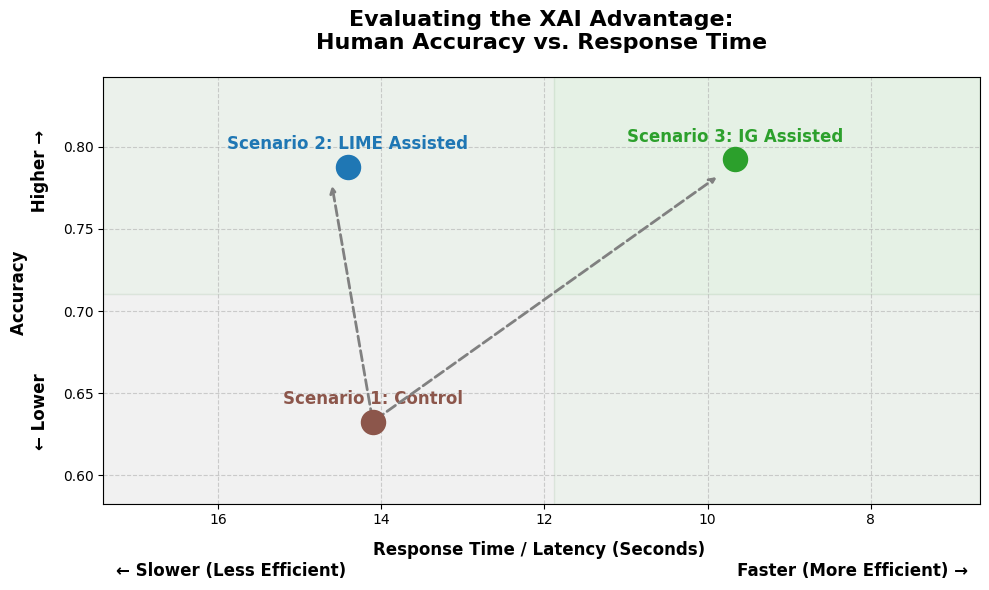

In [14]:
fig1, ax1 = plt.subplots(figsize=(10, 6))
for i in range(len(scenarios_keys)):
    ax1.scatter(latency_vals[i], accuracy_vals[i], color=colors[i], s=300, label=display_names[i], zorder=5)
    ax1.text(latency_vals[i], accuracy_vals[i] + 0.008, display_names[i], fontsize=12, 
ha='center', va='bottom', fontweight='bold', color=colors[i])

# Draw narrative arrows showing the "XAI Advantage" from Control to Assisted models
# (data coordinates, so these stay correct regardless of axis direction)
ax1.annotate('', 
xy=(latency_vals[1]+0.2, accuracy_vals[1]-0.01), 
xytext=(latency_vals[0], accuracy_vals[0]),
arrowprops=dict(arrowstyle="->", color="gray", lw=2, ls="--"))
ax1.annotate('', 
xy=(latency_vals[2]+0.2, accuracy_vals[2]-0.01), 
xytext=(latency_vals[0], accuracy_vals[0]),
arrowprops=dict(arrowstyle="->", color="gray", lw=2, ls="--"))

# Dynamic Axis Limits — descending (larger latency on left, smaller on right)
ax1.set_xlim(max(latency_vals) + 3, min(latency_vals) - 3)
ax1.set_ylim(min(accuracy_vals) - 0.05, max(accuracy_vals) + 0.05)
ax1.set_title('Evaluating the XAI Advantage:\nHuman Accuracy vs. Response Time', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Response Time / Latency (Seconds) \n← Slower (Less Efficient)                                                                    Faster (More Efficient) →', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('Accuracy \n← Lower                            Higher →', fontsize=12, fontweight='bold', labelpad=10)

# Quadrant shading using dynamic midpoints
# Colors are swapped vs. before: get_xlim()[0] is now the MAX latency value (slow/bad),
# and get_xlim()[1] is the MIN latency value (fast/good), since the axis is reversed.
mid_lat = np.mean([latency_vals[0], latency_vals[2]])
mid_acc = np.mean([accuracy_vals[0], accuracy_vals[1]])
ax1.axvspan(ax1.get_xlim()[0], mid_lat, color='gray', alpha=0.05, zorder=0)   # high-latency side
ax1.axvspan(mid_lat, ax1.get_xlim()[1], color='green', alpha=0.05, zorder=0) # low-latency side
ax1.axhspan(ax1.get_ylim()[0], mid_acc, color='gray', alpha=0.05, zorder=0) 
ax1.axhspan(mid_acc, ax1.get_ylim()[1], color='green', alpha=0.05, zorder=0) 
ax1.grid(True, linestyle='--', alpha=0.6, zorder=1)
plt.tight_layout()
plt.show()

## Key Takeaways
* The XAI Advantage is real, but it's not symmetric across both methods:
    * Control sits on the lower left (the least efficient region), while both LIME and IG both move up into the higher-accuracy zone. But only IG moves further right (faster) than Control & LIME, consistent with the latency test above. 

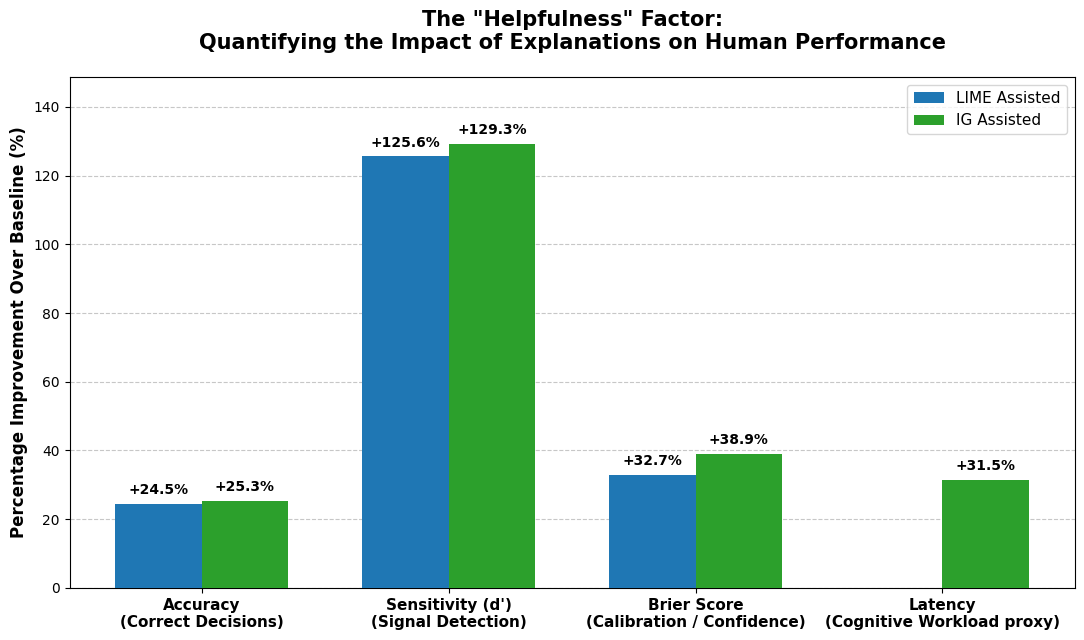

In [15]:
# Helper function to calculate percentage change using the group averages
def calc_improvement(assisted_array, control_array, lower_is_better=False):
    # Calculate the grand mean for each group's array
    assisted_mean = np.mean(assisted_array)
    control_mean = np.mean(control_array)
    
    if lower_is_better:
        return ((control_mean - assisted_mean) / control_mean) * 100
    return ((assisted_mean - control_mean) / control_mean) * 100

ctrl = group_metrics[CTRL_KEY]
lime = group_metrics[LIME_KEY]
ig   = group_metrics[IG_KEY]

lime_improvements = [
    calc_improvement(lime['accuracy'], ctrl['accuracy']),
    calc_improvement(lime['d_prime'],  ctrl['d_prime']),
    calc_improvement(lime['brier'],    ctrl['brier'], lower_is_better=True),
    calc_improvement(lime['latency'],  ctrl['latency'], lower_is_better=True)
]

ig_improvements = [
    calc_improvement(ig['accuracy'], ctrl['accuracy']),
    calc_improvement(ig['d_prime'],  ctrl['d_prime']),
    calc_improvement(ig['brier'],    ctrl['brier'], lower_is_better=True),
    calc_improvement(ig['latency'],  ctrl['latency'], lower_is_better=True)
]

metrics_labels = ['Accuracy\n(Correct Decisions)', 'Sensitivity (d\')\n(Signal Detection)',
                  'Brier Score\n(Calibration / Confidence)', 'Latency\n(Cognitive Workload proxy)']

x = np.arange(len(metrics_labels))
width = 0.35

fig2, ax2 = plt.subplots(figsize=(11, 6.5))

rects1 = ax2.bar(x - width/2, lime_improvements, width, label='LIME Assisted', color=color_map[LIME_KEY], zorder=3)
rects2 = ax2.bar(x + width/2, ig_improvements, width, label='IG Assisted', color=color_map[IG_KEY], zorder=3)

ax2.set_ylabel('Percentage Improvement Over Baseline (%)', fontsize=12, fontweight='bold')
ax2.set_title('The "Helpfulness" Factor:\nQuantifying the Impact of Explanations on Human Performance', fontsize=15, fontweight='bold', pad=20)
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_labels, fontsize=11, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax2.annotate(f'+{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=10)

autolabel(rects1)
autolabel(rects2)

# Dynamic Y-limit to ensure labels don't get cut off
max_imp = max(max(lime_improvements), max(ig_improvements))
ax2.set_ylim(0, max_imp + (max_imp * 0.15))

plt.tight_layout()
plt.show()

## Key Takeaways
* each XAI condition improved over Control on three of the four metrics, but not latency uniformly. Only IG was significantly faster than Control (p= 0.0064) whereas LIME showed no significant speed improvment over control (p = 0.8772), which is why its latency bar is near-zero in the chart
* the main headline is the comparable gains in accuracy and the large jump in sensitivity (d') compared to Control. This means that XAI is able to sharpened the participant's ability to discriminate phishing from legit emails
* Improvement in Brier Score meaning that it helps improve participants' calibration rather than actual accuracy. Participants felt appropriately assured when they were likely to be rigth, and properly uncertain when they were likely to be wrong.